In [1]:
import sys
sys.path.append("..")

import yaml
import random
import shutil
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import cv2
import warnings
warnings.filterwarnings("ignore")

from src.config import DATA_RAW_DIR, LABELS_FOLDER, IMAGES_FOLDER, ROOT_DIR

# Check the yaml that came with the dataset
visdrone_yaml = DATA_RAW_DIR / "visdrone.yaml"
if visdrone_yaml.exists():
    with open(visdrone_yaml) as f:
        content = yaml.safe_load(f)
    print("Found visdrone.yaml — contents:")
    print(yaml.dump(content, default_flow_style=False))
else:
    print("No visdrone.yaml found in raw folder")

Found visdrone.yaml — contents:
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
nc: 10
path: ./VisDrone_Dataset
test: VisDrone2019-DET-test-dev/images
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images



In [2]:
lbl_dir = DATA_RAW_DIR / "VisDrone2019-DET-train" / LABELS_FOLDER
all_class_ids = Counter()

for lbl_file in lbl_dir.glob("*.txt"):
    with open(lbl_file) as f:
        for line in f:
            vals = line.strip().split()
            if vals:
                all_class_ids[int(vals[0])] += 1

print(f"{'Class ID':<10} {'Count':>12}")
print("─" * 24)
for cid in sorted(all_class_ids):
    print(f"{cid:<10} {all_class_ids[cid]:>12,}")

print(f"\nTotal objects : {sum(all_class_ids.values()):,}")
print(f"Unique classes: {len(all_class_ids)}")
print(f"\nMax class ID  : {max(all_class_ids.keys())}")
print(f"Min class ID  : {min(all_class_ids.keys())}")

Class ID          Count
────────────────────────
0                79,337
1                27,059
2                10,480
3               144,867
4                24,956
5                12,875
6                 4,812
7                 3,246
8                 5,926
9                29,647

Total objects : 343,205
Unique classes: 10

Max class ID  : 9
Min class ID  : 0


In [3]:
lbl_dir   = DATA_RAW_DIR / "VisDrone2019-DET-train" / LABELS_FOLDER
img_dir   = DATA_RAW_DIR / "VisDrone2019-DET-train" / IMAGES_FOLDER
sample    = random.choice(list(lbl_dir.glob("*.txt")))
img_file  = img_dir / (sample.stem + ".jpg")

img = cv2.imread(str(img_file))
ih, iw = img.shape[:2]

print(f"Image : {sample.stem}.jpg  ({iw}×{ih}px)\n")
print(f"{'Line':<5} {'ClassID':<9} {'CX':>6} {'CY':>6} {'W':>6} {'H':>6}  {'Valid?'}")
print("─" * 52)

errors = 0
with open(sample) as f:
    for i, line in enumerate(f):
        vals = line.strip().split()
        if len(vals) != 5:
            print(f"{i:<5} ← BAD LINE: {line.strip()}")
            errors += 1
            continue
        cid = int(vals[0])
        cx, cy, w, h = map(float, vals[1:])
        valid = "✅" if (0<=cx<=1 and 0<=cy<=1 and 0<w<=1 and 0<h<=1) else "⚠️ out of range"
        print(f"{i:<5} {cid:<9} {cx:>6.3f} {cy:>6.3f} {w:>6.3f} {h:>6.3f}  {valid}")
        if i > 10: print("  ... (showing first 10 only)"); break

print(f"\nFormat errors: {errors}")

Image : 0000279_05801_d_0000610.jpg  (1360×765px)

Line  ClassID       CX     CY      W      H  Valid?
────────────────────────────────────────────────────
0     3          0.417  0.204  0.005  0.016  ✅
1     3          0.401  0.209  0.013  0.008  ✅
2     3          0.403  0.206  0.010  0.007  ✅
3     4          0.394  0.214  0.018  0.014  ✅
4     3          0.426  0.213  0.006  0.008  ✅
5     0          0.412  0.216  0.002  0.009  ✅
6     3          0.396  0.244  0.007  0.009  ✅
7     3          0.367  0.265  0.008  0.012  ✅
8     5          0.378  0.254  0.029  0.017  ✅
9     4          0.378  0.274  0.013  0.025  ✅
10    0          0.386  0.269  0.004  0.018  ✅
11    3          0.401  0.275  0.010  0.017  ✅
  ... (showing first 10 only)

Format errors: 0


In [4]:
# Standard VisDrone class names by ID
VISDRONE_ALL_CLASSES = {
    0: "pedestrian",
    1: "people",
    2: "bicycle",
    3: "car",
    4: "van",
    5: "truck",
    6: "tricycle",
    7: "awning-tricycle",
    8: "bus",
    9: "motor"
}

# Get all class IDs found in training labels
found_ids   = sorted(all_class_ids.keys())
found_names = [VISDRONE_ALL_CLASSES.get(i, f"class_{i}") for i in found_ids]

print("Classes found in your dataset:")
for cid, name in zip(found_ids, found_names):
    print(f"  {cid}: {name}  ({all_class_ids[cid]:,} objects)")

# Write the dataset.yaml using ALL found classes
# (YOLO needs contiguous IDs starting from 0)
dataset_config = {
    "path": str(DATA_RAW_DIR).replace("\\", "/"),
    "train": "VisDrone2019-DET-train/images",
    "val"  : "VisDrone2019-DET-val/images",
    "test" : "VisDrone2019-DET-test-dev/images",
    "nc"   : len(found_ids),
    "names": found_names
}

yaml_path = ROOT_DIR / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_config, f, default_flow_style=False, sort_keys=False)

print(f"\n✅ dataset.yaml written → {yaml_path}")
print(f"   nc (num classes): {len(found_ids)}")
print(f"   names: {found_names}")

Classes found in your dataset:
  0: pedestrian  (79,337 objects)
  1: people  (27,059 objects)
  2: bicycle  (10,480 objects)
  3: car  (144,867 objects)
  4: van  (24,956 objects)
  5: truck  (12,875 objects)
  6: tricycle  (4,812 objects)
  7: awning-tricycle  (3,246 objects)
  8: bus  (5,926 objects)
  9: motor  (29,647 objects)

✅ dataset.yaml written → D:\drone-detection\dataset.yaml
   nc (num classes): 10
   names: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']


In [5]:
# Show what CLASS_NAMES should be in config.py
print("Update your src/config.py CLASS_NAMES to:")
print()
print("CLASS_NAMES = {")
for i, (cid, name) in enumerate(zip(found_ids, found_names)):
    print(f"    {cid}: '{name}',")
print("}")

# Also show which classes are humans vs cars for counting logic
print()
print("For counting logic:")
human_ids = [cid for cid, name in zip(found_ids, found_names)
             if name in ("pedestrian", "people")]
car_ids   = [cid for cid, name in zip(found_ids, found_names)
             if name in ("car", "van")]
print(f"  HUMAN_CLASS_IDS = {human_ids}")
print(f"  CAR_CLASS_IDS   = {car_ids}")

Update your src/config.py CLASS_NAMES to:

CLASS_NAMES = {
    0: 'pedestrian',
    1: 'people',
    2: 'bicycle',
    3: 'car',
    4: 'van',
    5: 'truck',
    6: 'tricycle',
    7: 'awning-tricycle',
    8: 'bus',
    9: 'motor',
}

For counting logic:
  HUMAN_CLASS_IDS = [0, 1]
  CAR_CLASS_IDS   = [3, 4]


In [6]:
# ─── Final Class Config (from dataset) ───────────────────────
HUMAN_CLASS_IDS = [0, 1]   # pedestrian + people → count as humans
CAR_CLASS_IDS   = [3, 4]   # car + van           → count as cars

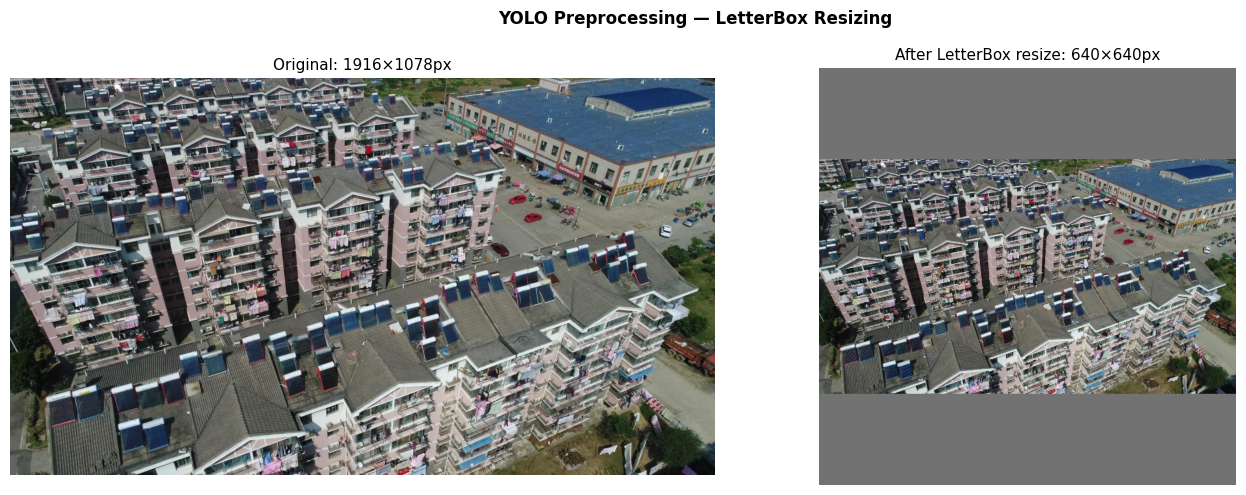

Saved → assets/sample_images/letterbox_preview.png


In [7]:
from ultralytics.data.augment import LetterBox
from ultralytics import YOLO
import matplotlib.pyplot as plt

img_dir    = DATA_RAW_DIR / "VisDrone2019-DET-train" / IMAGES_FOLDER
sample_img = cv2.imread(str(random.choice(list(img_dir.glob("*.jpg")))))
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# Show original vs letterboxed (what YOLO does before feeding to model)
lb        = LetterBox(new_shape=(640, 640))
result    = lb(image=sample_img)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(sample_rgb)
axes[0].set_title(f"Original: {sample_img.shape[1]}×{sample_img.shape[0]}px", fontsize=11)
axes[0].axis("off")

axes[1].imshow(result_rgb)
axes[1].set_title("After LetterBox resize: 640×640px", fontsize=11)
axes[1].axis("off")

plt.suptitle("YOLO Preprocessing — LetterBox Resizing", fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/sample_images/letterbox_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → assets/sample_images/letterbox_preview.png")

In [8]:
import yaml

yaml_path = ROOT_DIR / "dataset.yaml"
with open(yaml_path) as f:
    config = yaml.safe_load(f)

print("Final dataset.yaml contents:")
print("─" * 40)
for key, val in config.items():
    print(f"{key}: {val}")

print()
# Quick sanity check
train_img_dir = Path(config["path"]) / config["train"]
val_img_dir   = Path(config["path"]) / config["val"]
print(f"Train images exist: {'✅' if train_img_dir.exists() else '❌'} ({train_img_dir})")
print(f"Val images exist  : {'✅' if val_img_dir.exists() else '❌'} ({val_img_dir})")
print(f"Num classes (nc)  : {config['nc']}")
print(f"Class names       : {config['names']}")

Final dataset.yaml contents:
────────────────────────────────────────
path: D:/drone-detection/data/raw/VisDrone
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-dev/images
nc: 10
names: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']

Train images exist: ✅ (D:\drone-detection\data\raw\VisDrone\VisDrone2019-DET-train\images)
Val images exist  : ✅ (D:\drone-detection\data\raw\VisDrone\VisDrone2019-DET-val\images)
Num classes (nc)  : 10
Class names       : ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
